<a href="https://colab.research.google.com/github/springboardmentorLive/Reality_AI/blob/NITISHA_SHINY/Copy_of_Image_segmentation_rgb_hsvf30.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

batch_size = 32
img_height = 180
img_width = 180


In [ ]:
import tensorflow_datasets as tfds

(ds_train, ds_val), ds_info = tfds.load(
    "tf_flowers",
    split=["train[:80%]", "train[80%:]"],
    with_info=True,
    as_supervised=True
)

def format_image(image, label):
    image = tf.image.resize(image, (img_height, img_width))
    return image, label

train_ds = ds_train.map(format_image).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_ds = ds_val.map(format_image).batch(batch_size).prefetch(tf.data.AUTOTUNE)

class_names = ds_info.features["label"].names
print("Classes:", class_names)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.SED2BH_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
Classes: ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']


In [ ]:
for image_batch, labels_batch in train_ds:
    print(image_batch.shape)
    print(labels_batch.shape)
    break


(32, 180, 180, 3)
(32,)


In [ ]:
num_classes = len(class_names)

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)


Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 187s 2s/step - accuracy: 0.3152 - loss: 2.8610 - val_accuracy: 0.5368 - val_loss: 1.1151
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 194s 2s/step - accuracy: 0.5973 - loss: 1.0572 - val_accuracy: 0.5967 - val_loss: 0.9733
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 187s 2s/step - accuracy: 0.7409 - loss: 0.7153 - val_accuracy: 0.6199 - val_loss: 1.0298
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 192s 2s/step - accuracy: 0.8835 - loss: 0.3827 - val_accuracy: 0.5913 - val_loss: 1.3028
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 200s 2s/step - accuracy: 0.9133 - loss: 0.2556 - val_accuracy: 0.5858 - val_loss: 1.5006


In [ ]:
import matplotlib.pyplot as plt


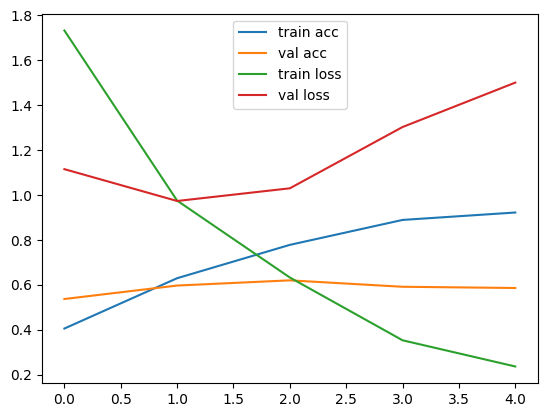

In [ ]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()


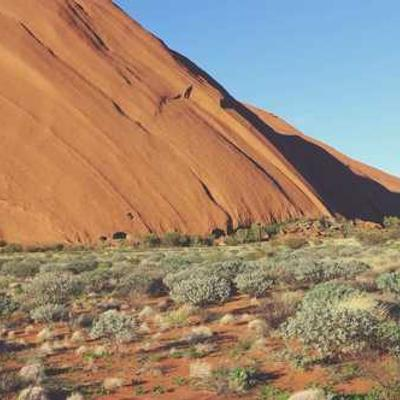

In [ ]:
from PIL import Image
from IPython.display import display
import requests
from io import BytesIO

url = "https://picsum.photos/400"
response = requests.get(url)

img = Image.open(BytesIO(response.content))
display(img)

img.save("on.png")


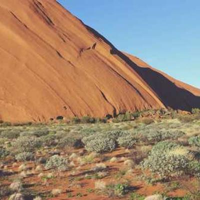

In [ ]:
resized_image = img.resize((200,200))
resized_image

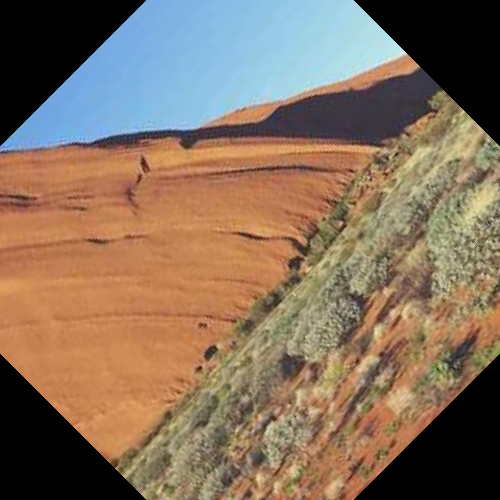

In [ ]:
rotated_image = img.resize((500,500)).rotate(45)
rotated_image

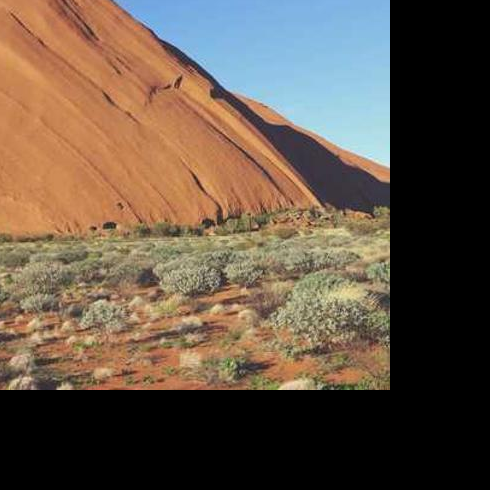

In [ ]:
crop_image = img.crop((10,10,500,500))
crop_image

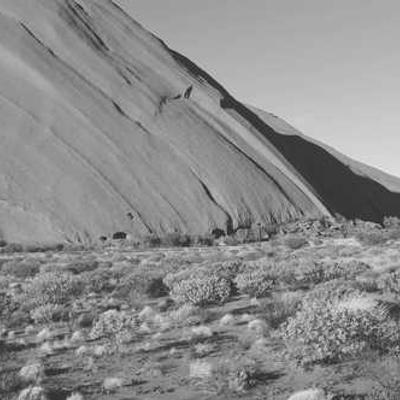

In [ ]:
grayscale = img.convert("L")
grayscale

RGB to Gray Scale

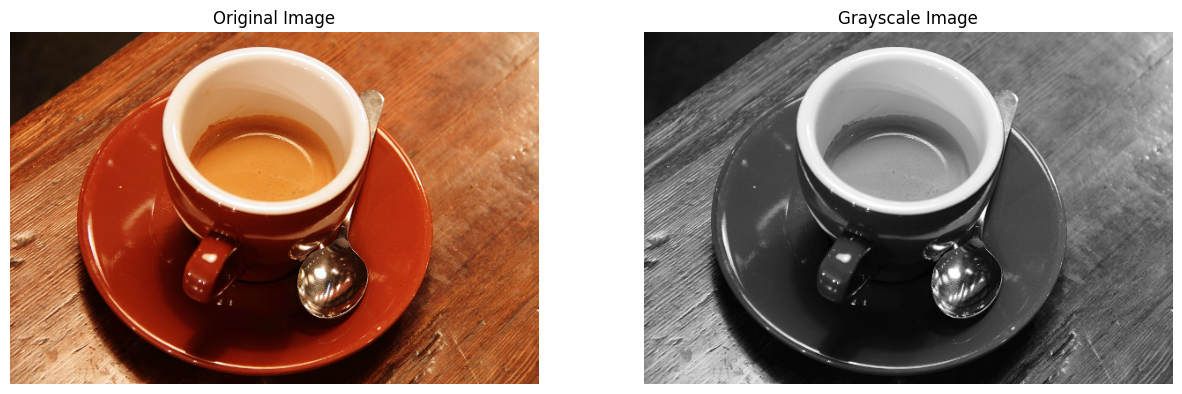

In [ ]:
# Importing Necessary Libraries from skimage
from skimage import data
from skimage.color import rgb2gray

import matplotlib.pyplot as plt

# Setting the plot size
plt.figure(figsize=(15, 15))

# Sample Image of scikit-image package
coffee = data.coffee()

plt.subplot(1, 2, 1)

# Displaying the sample image
plt.imshow(coffee)
plt.title("Original Image")
plt.axis("off")

# Converting RGB image to Monochrome
gray_coffee = rgb2gray(coffee)

plt.subplot(1, 2, 2)

# Displaying the monochrome image
plt.imshow(gray_coffee, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.show()


CONVERTING RGB TO HSV

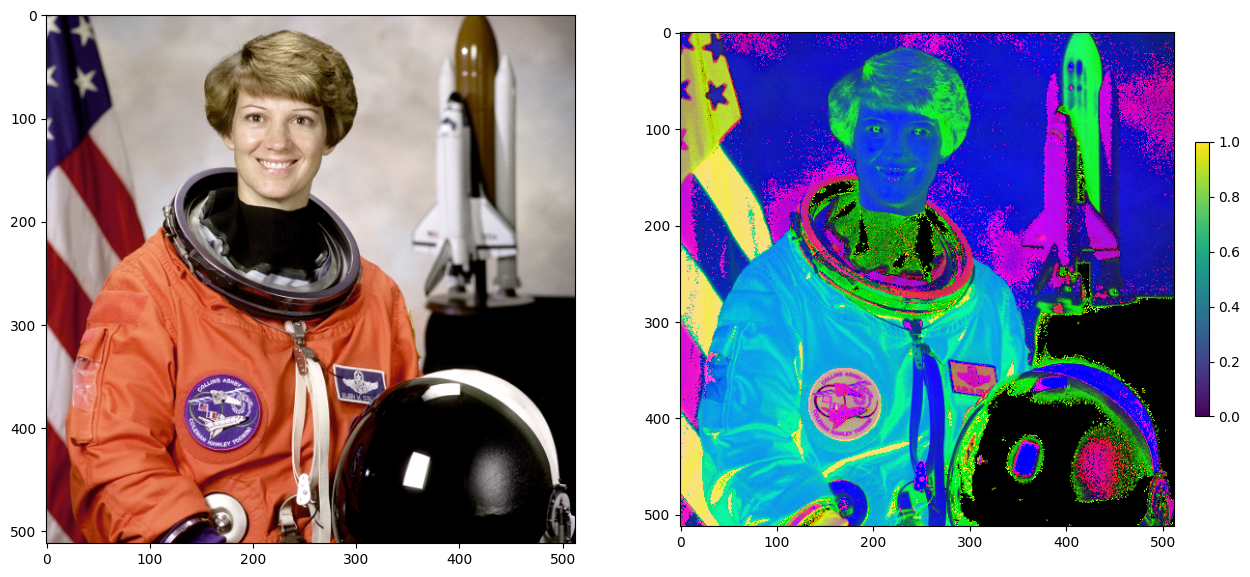

In [ ]:
# Importing Necessary Libraries
from skimage import data
from skimage.color import rgb2hsv
import matplotlib.pyplot as plt

# Setting the plot size to 15,15
plt.figure(figsize=(15, 15))

# Sample Image of scikit-image package
astronaut = data.astronaut()

plt.subplot(1, 2, 1)

# Displaying the sample image
plt.imshow(astronaut)

# Converting RGB Image to HSV Image
hsv_astronaut = rgb2hsv(astronaut)

plt.subplot(1, 2, 2)

# Displaying the sample image HSV Format
hsv_astronaut_colorbar = plt.imshow(hsv_astronaut)

# Adjusting colorbar to fit the size of the image
plt.colorbar(hsv_astronaut_colorbar, fraction=0.026, pad=0.04)
